**MATEMATIKA DISKRIT KLASIFIKASI GAJI PEKERJA DI INDONESIA**

**MARIA DWI KURNIASIH 240830010003**

**HIZKIA SAMHAN REZAYOSHI 24083010019**

**NAJWA SOFIA 24083010115**

In [219]:
import pandas as pd
import numpy as np

# --- 1. Memuat Data ---
df = pd.read_excel("Gaji.xlsx")
df 

,Provinsi,Industri,Tenaga Kepemimpinan,Tata usaha,Penjualan,Jasa,Pertanian,Pekerja Kasar
0,Aceh,2.849632e+06,3.598366e+06,3.001899e+06,2.157564e+06,1.919875e+06,2.284831e+06,2.252625e+06
1,Sumatera Utara,3.126435e+06,4.364995e+06,3.185648e+06,2.525893e+06,1.773734e+06,2.546798e+06,2.656851e+06
2,Sumatera Barat,3.318996e+06,5.332000e+06,2.867383e+06,2.450512e+06,2.277002e+06,2.217883e+06,2.322214e+06
3,Riau,3.755738e+06,5.512338e+06,3.188229e+06,2.484849e+06,2.180139e+06,2.634460e+06,3.239247e+06
4,Jambi,3.468120e+06,4.819097e+06,3.058750e+06,2.119359e+06,2.397606e+06,2.208997e+06,2.803159e+06
5,Sumatera Selatan,3.375189e+06,4.803239e+06,3.685998e+06,2.422849e+06,1.927298e+06,2.014906e+06,2.937111e+06
6,Bengkulu,3.359707e+06,5.139315e+06,2.953959e+06,2.137535e+06,1.693929e+06,1.909284e+06,2.410860e+06
7,Lampung,2.703824e+06,5.491139e+06,2.841753e+06,2.407363e+06,1.581052e+06,2.162303e+06,2.380377e+06
8,Kepulauan Bangka Belitung,4.261173e+06,5.420088e+06,3.997652e+06,2.645142e+06,2.238017e+06,2.622879e+06,2.906712e+06
9,Kepulauan Riau,5.813965e+06,8.950320e+06,4.985380e+06,4.002888e+06,2.867940e+06,2.502404e+06,4.882255e+06


In [221]:
 #Definisikan kolom fitur
features = ['Industri','Tenaga Kepemimpinan', 'Tata usaha', 'Penjualan', 'Jasa', 'Pertanian ', 'Pekerja Kasar']
# --- 2. Pembersihan Data dan Imputasi Median ---
for col in features:
    # Konversi ke numerik; errors='coerce' mengubah nilai non-numerik (termasuk blank) menjadi NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Imputasi Missing Value (NaN) menggunakan Median dari kolom tersebut
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("Langkah 1 Selesai: Data telah dimuat, dikonversi ke numerik, dan diimputasi.")
print("-" * 50)

Langkah 1 Selesai: Data telah dimuat, dikonversi ke numerik, dan diimputasi.
--------------------------------------------------


Ambang Batas Median Nasional (Thresholds) telah dihitung:
- Industri: 3673738.0
- Tenaga Kepemimpinan: 5057545.7
- Tata usaha: 3412653.5
- Penjualan: 2498412.1
- Jasa: 2257509.2
- Pertanian : 2373090.4
- Pekerja Kasar: 2921911.2
--------------------------------------------------
Langkah 2 Selesai: Kode DPI telah dibuat untuk setiap provinsi.
--------------------------------------------------


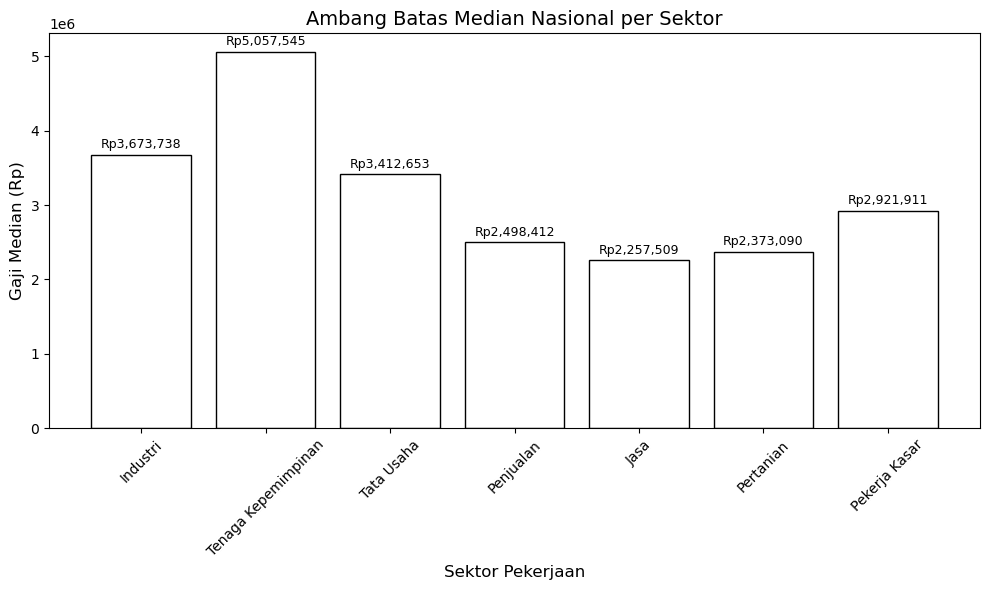

In [223]:
import pandas as pd
import numpy as np

# --- Reload Data and re-apply cleaning steps to ensure correct df state ---
# The 'features' list is assumed to be defined in a previous cell.
# If not, please define it before this cell or uncomment the line below:
# features = ['Tenaga profesional/ Teknisi','Tenaga Kepemimpinan', 'Tata usaha', 'Penjualan', 'jasa', 'Petani', 'Buruh', 'Lainnya']

df = pd.read_excel("Gaji.xlsx")
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# --- 3. Penentuan Ambang Batas Diskrit (Median Nasional) ---
thresholds = {col: df[col].median() for col in features}

print("Ambang Batas Median Nasional (Thresholds) telah dihitung:")
for k, v in thresholds.items():
    print(f"- {k}: {v:.1f}")
print("-" * 50)

# --- 4. Fungsi Klasifikasi Indeks Profil Diskrit (DPI) ---

def classify_dpi(row, features, thresholds):
    """
    Mengklasifikasikan provinsi menjadi Vektor Biner 3-Digit (DPI)
    berdasarkan perbandingan Boolean terhadap Median Nasional.
    """
    binary_list = []

    # P (Pertanian): Posisike-1 di kode biner
    if row['Industri'] > thresholds['Industri']:
        binary_list.append('1') # Tinggi (Di atas median)
    else:
        binary_list.append('0') # Rendah (Di bawah atau sama dengan median)

    # I (Industri): Posisi ke-2 di kode biner
    if row['Tenaga Kepemimpinan'] > thresholds['Tenaga Kepemimpinan']:
        binary_list.append('1')
    else:
        binary_list.append('0')

    # J (Jasa): Posisi ke-3 di kode biner
    if row['Penjualan'] > thresholds['Penjualan']:
        binary_list.append('1')
    else:
        binary_list.append('0')

    if row['Jasa'] > thresholds['Jasa']:
        binary_list.append('1')
    else:
        binary_list.append('0')

    if row['Pertanian '] > thresholds['Pertanian ']:
        binary_list.append('1')
    else:
        binary_list.append('0')

    if row['Pekerja Kasar'] > thresholds['Pekerja Kasar']:
        binary_list.append('1')
    else:
        binary_list.append('0')

    # Hasil: Kode Diskrit 3-Digit (misalnya, '101')
    return "".join(binary_list)

# Terapkan fungsi klasifikasi DPI ke seluruh data
df['DPI_Code'] = df.apply(lambda row: classify_dpi(row, features, thresholds), axis=1)

print("Langkah 2 Selesai: Kode DPI telah dibuat untuk setiap provinsi.")
print("-" * 50)

# Data sektor dan ambang batas median
sektor = ['Industri', 'Tenaga Kepemimpinan', 'Tata Usaha', 'Penjualan', 'Jasa', 'Pertanian', 'Pekerja Kasar']
median_gaji = [3673738.0, 5057545.7, 3412653.5, 2498412.1, 2257509.2, 2373090.4, 2921911.2]

# Membuat bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(sektor, median_gaji, color='white', edgecolor='black')

# Memberi label tiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50000, f'Rp{int(yval):,}', ha='center', va='bottom', fontsize=9)

# Judul dan label sumbu
plt.title('Ambang Batas Median Nasional per Sektor', fontsize=14)
plt.ylabel('Gaji Median (Rp)', fontsize=12)
plt.xlabel('Sektor Pekerjaan', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [232]:
import pandas as pd

# =============================
# 1. LOAD DATA
# =============================
df = pd.read_excel("Gaji.xlsx")

# Daftar kolom upah sesuai file
features = [
    'Industri',
    'Tenaga Kepemimpinan',
    'Tata usaha',
    'Penjualan',
    'Jasa',
    'Pertanian ',
    'Pekerja Kasar'
]

# =============================
# 2. HITUNG MEDIAN NASIONAL
# =============================
median_values = df[features].median()

# =============================
# 3. BENTUK KODE DPI (8 bit)
# =============================
def make_dpi_code(row):
    code = ""
    for col in features:
        if row[col] >= median_values[col]:
            code += "1"
        else:
            code += "0"
    return code

df["DPI_Code"] = df.apply(make_dpi_code, axis=1)

# =============================
# 4. INTERPRETASI KODE DPI
# =============================

sector_map = {
    0: "Industri",
    1: "Tenaga Kepemimpinan",
    2: "Tata Usaha",
    3: "Penjualan",
    4: "Jasa",
    5: "Pertanian ",
    6: "Pekerja Kasar"
}

def interpret_dpi(code):
    """Interpretasi otomatis berdasarkan bit 1/0 dari DPI_Code."""
    aktif = []

    for i, bit in enumerate(code):
        if bit == '1':
            aktif.append(sector_map[i])

    if len(aktif) == 0:
        return "Pola: Semua sektor upah di bawah median nasional"
    else:
        return "Upah kompetitif pada sektor: " + ", ".join(aktif)

df["DPI_Profile"] = df["DPI_Code"].apply(interpret_dpi)

print("\n*** HASIL KLASIFIKASI INDEKS PROFIL UPAH DISKRIT (DPI) ***")
print("Klasifikasi berdasarkan Logika Boolean dan Ambang Median Upah Nasional.\n")

print("Top 5 Hasil Klasifikasi:")
results = df[['Provinsi', 'DPI_Code', 'DPI_Profile'] + features]
print(results.head().to_markdown(index=False))

print("\nRingkasan Jumlah Provinsi per Profil Upah Diskrit:")
summary_df = df.groupby('DPI_Profile').size().sort_values(ascending=False).reset_index()
summary_df.columns = ['DPI Profile', 'Jumlah Provinsi']
print(summary_df.to_markdown(index=False, numalign="left"))



*** HASIL KLASIFIKASI INDEKS PROFIL UPAH DISKRIT (DPI) ***
Klasifikasi berdasarkan Logika Boolean dan Ambang Median Upah Nasional.

Top 5 Hasil Klasifikasi:
| Provinsi       |   DPI_Code | DPI_Profile                                                                           |    Industri |   Tenaga Kepemimpinan |   Tata usaha |   Penjualan |        Jasa |   Pertanian  |   Pekerja Kasar |
|:---------------|-----------:|:--------------------------------------------------------------------------------------|------------:|----------------------:|-------------:|------------:|------------:|-------------:|----------------:|
| Aceh           |    0000000 | Pola: Semua sektor upah di bawah median nasional                                      | 2.84963e+06 |           3.59837e+06 |  3.0019e+06  | 2.15756e+06 | 1.91988e+06 |  2.28483e+06 |     2.25262e+06 |
| Sumatera Utara |    0001010 | Upah kompetitif pada sektor: Penjualan, Pertanian                                     | 3.12643e+06 |       

In [238]:
# Salin dataframe yang ingin ditampilkan
results_slide = df[['Provinsi', 'DPI_Code', 'DPI_Profile', 
                    'Industri', 'Tenaga Kepemimpinan', 'Tata usaha', 
                    'Penjualan', 'Jasa', 'Pertanian ', 'Pekerja Kasar']].copy()

# Format gaji menjadi jutaan, 2 desimal
gaji_cols = ['Industri', 'Tenaga Kepemimpinan', 'Tata usaha', 
             'Penjualan', 'Jasa', 'Pertanian ', 'Pekerja Kasar']

for col in gaji_cols:
    results_slide[col] = results_slide[col].apply(lambda x: f"{x/1_000_000:.2f} jt")

# Tampilkan top 5 provinsi dengan format siap slide
print("\nTop 5 Hasil Klasifikasi DPI:")
print(results_slide.head().to_markdown(index=False))



Top 5 Hasil Klasifikasi DPI:
| Provinsi       |   DPI_Code | DPI_Profile                                                                           | Industri   | Tenaga Kepemimpinan   | Tata usaha   | Penjualan   | Jasa    | Pertanian    | Pekerja Kasar   |
|:---------------|-----------:|:--------------------------------------------------------------------------------------|:-----------|:----------------------|:-------------|:------------|:--------|:-------------|:----------------|
| Aceh           |    0000000 | Pola: Semua sektor upah di bawah median nasional                                      | 2.85 jt    | 3.60 jt               | 3.00 jt      | 2.16 jt     | 1.92 jt | 2.28 jt      | 2.25 jt         |
| Sumatera Utara |    0001010 | Upah kompetitif pada sektor: Penjualan, Pertanian                                     | 3.13 jt    | 4.36 jt               | 3.19 jt      | 2.53 jt     | 1.77 jt | 2.55 jt      | 2.66 jt         |
| Sumatera Barat |    0100100 | Upah kompetitif pada s

In [193]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

# Hitung rata-rata gaji semua sektor untuk tiap provinsi
df['Rata_rata_Gaji'] = df[['Industri','Tenaga Kepemimpinan','Tata usaha',
                           'Penjualan','Jasa','Pertanian ','Pekerja Kasar']].mean(axis=1)

# Klasifikasikan rata-rata gaji menjadi 3 kategori: Rendah, Sedang, Tinggi
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform', subsample=None)
df['Kategori_Gaji'] = kbd.fit_transform(df[['Rata_rata_Gaji']]).astype(int).flatten()

print(df[['Provinsi','Rata_rata_Gaji','Kategori_Gaji']])


                     Provinsi  Rata_rata_Gaji  Kategori_Gaji
0                        Aceh    2.580685e+06              0
1              Sumatera Utara    2.882907e+06              0
2              Sumatera Barat    2.969427e+06              0
3                       Riau     3.285000e+06              0
4                       Jambi    2.982155e+06              0
5            Sumatera Selatan    3.023799e+06              0
6                    Bengkulu    2.800656e+06              0
7                     Lampung    2.795402e+06              0
8   Kepulauan Bangka Belitung    3.441666e+06              0
9              Kepulauan Riau    4.857879e+06              1
10                DKI Jakarta    6.540602e+06              2
11                 Jawa Barat    4.542345e+06              1
12                Jawa Tengah    2.805686e+06              0
13              DI Yogyakarta    3.189529e+06              0
14                 Jawa Timur    3.084714e+06              0
15                     B

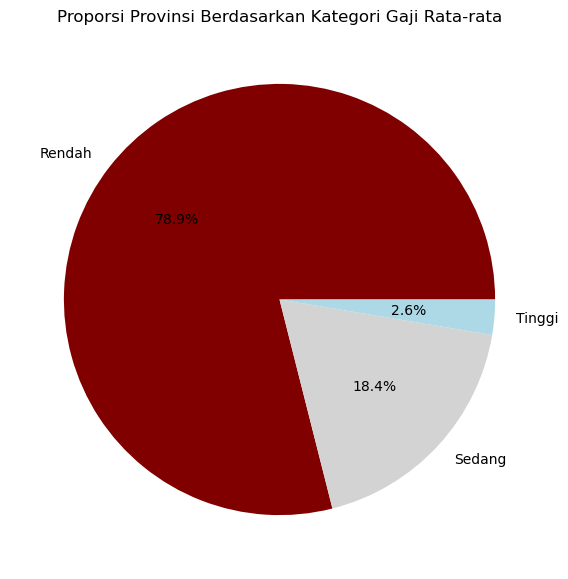

In [195]:
import matplotlib.pyplot as plt

# Hitung jumlah provinsi per kategori gaji
kategori_counts = df['Kategori_Gaji'].value_counts().sort_index()  # 0,1,2
kategori_labels = ['Rendah', 'Sedang', 'Tinggi']

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(kategori_counts, labels=kategori_labels, autopct='%1.1f%%', colors=['maroon','lightgrey','lightblue'])
plt.title("Proporsi Provinsi Berdasarkan Kategori Gaji Rata-rata")
plt.show()




In [197]:
# -------------------------
# 3. OPERASI LOGIKA
# -------------------------

# Misal:
# P(x): Penjualan > Jasa
# Q(x): Tata usaha > Pekerja Kasar

df["P_Penjualan_gt_Jasa"] = df["Penjualan"] > df["Jasa"]
df["Q_tu_gt_Pekerja Kasar"] = df["Tata usaha"] > df["Pekerja Kasar"]

df["P_and_Q"] = df["P_Penjualan_gt_Jasa"] & df["Q_tu_gt_Pekerja Kasar"]
df["P_or_Q"] = df["P_Penjualan_gt_Jasa"] | df["Q_tu_gt_Pekerja Kasar"]
df["P_implies_Q"] = (~df["P_Penjualan_gt_Jasa"]) | df["Q_tu_gt_Pekerja Kasar"]

print("\n=== Contoh operasi logika ===")
print(df[["Provinsi","P_Penjualan_gt_Jasa","Q_tu_gt_Pekerja Kasar","P_and_Q","P_or_Q","P_implies_Q"]].head())


=== Contoh operasi logika ===
         Provinsi  P_Penjualan_gt_Jasa  Q_tu_gt_Pekerja Kasar  P_and_Q  \
0            Aceh                 True                   True     True   
1  Sumatera Utara                 True                   True     True   
2  Sumatera Barat                 True                   True     True   
3           Riau                  True                  False    False   
4           Jambi                False                   True    False   

   P_or_Q  P_implies_Q  
0    True         True  
1    True         True  
2    True         True  
3    True        False  
4    True         True  


GRAF SELISIH GAJI

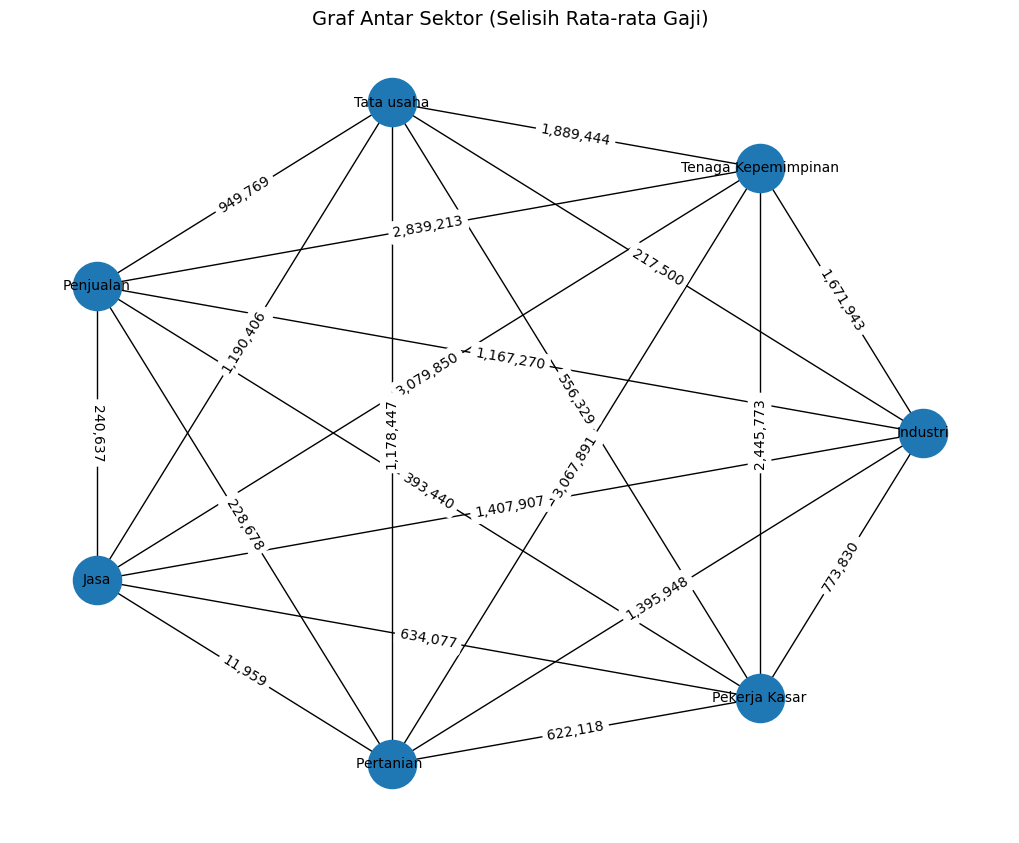

In [207]:
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt

# Kolom gaji numerik
gaji_cols = ['Industri', 'Tenaga Kepemimpinan', 'Tata usaha', 
             'Penjualan', 'Jasa', 'Pertanian ', 'Pekerja Kasar']

# Rata-rata gaji tiap sektor
avg_sector = df[gaji_cols].mean()

# Buat Graph kosong
S = nx.Graph()
S.add_nodes_from(gaji_cols)

# Tambahkan edge berdasarkan selisih rata-rata
for a, b in combinations(gaji_cols, 2):
    diff = abs(avg_sector[a] - avg_sector[b])
    S.add_edge(a, b, weight=diff)

# Visualisasi
plt.figure(figsize=(10,8))
pos = nx.circular_layout(S)
nx.draw(S, pos, with_labels=True, node_size=1200, font_size=10)

# Label edge
labels = nx.get_edge_attributes(S, "weight")
nx.draw_networkx_edge_labels(S, pos, edge_labels={k:f"{v:,.0f}" for k,v in labels.items()})

plt.title("Graf Antar Sektor (Selisih Rata-rata Gaji)", fontsize=14)
plt.show()


Kategori pekerjaan terdeteksi: ['Industri', 'Tenaga Kepemimpinan', 'Tata usaha', 'Penjualan', 'Jasa', 'Pertanian ', 'Pekerja Kasar']

    MST untuk kategori: Industri
Aceh -- Maluku, selisih gaji = 76509.94140361436
Aceh -- Lampung, selisih gaji = 145807.745257074
Sumatera Utara -- Jawa Timur, selisih gaji = 36333.129343240056
Sumatera Utara -- Maluku Utara, selisih gaji = 52934.787821244914
Sumatera Barat -- Bengkulu, selisih gaji = 40710.10977271106
Sumatera Barat -- Sulawesi Tenggara, selisih gaji = 55238.59860102739
Riau  -- Sulawesi Selatan, selisih gaji = 19951.16434142785
Riau  -- Kalimantan Tengah, selisih gaji = 51436.919882191345
Jambi -- Kalimantan Barat, selisih gaji = 33336.5606428287
Jambi -- Sumatera Selatan, selisih gaji = 92930.21713005425
Sumatera Selatan -- Bengkulu, selisih gaji = 15482.749343095347
Lampung -- Nusa Tenggara Barat, selisih gaji = 3930.751297786366
Kepulauan Bangka Belitung -- Papua Pegunungan, selisih gaji = 17966.612331927754
Kepulauan Bangka Belitu

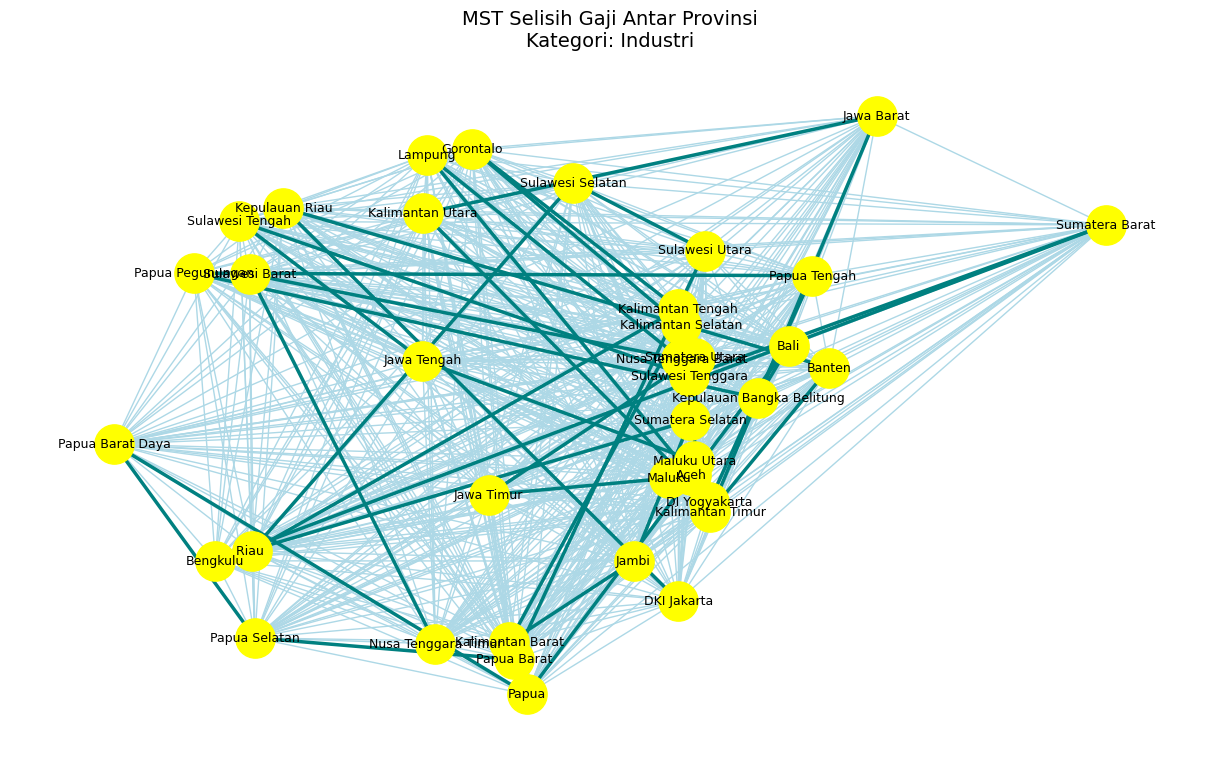


    MST untuk kategori: Tenaga Kepemimpinan
Aceh -- Papua Selatan, selisih gaji = 90972.57549125794
Aceh -- Banten, selisih gaji = 3598366.0565543408
Sumatera Utara -- Nusa Tenggara Barat, selisih gaji = 54543.419326063246
Sumatera Utara -- Nusa Tenggara Timur, selisih gaji = 561111.0005511148
Sumatera Barat -- Papua Barat Daya, selisih gaji = 18713.12452737149
Sumatera Barat -- Papua Barat, selisih gaji = 39034.38908592146
Riau  -- Lampung, selisih gaji = 21198.640876485966
Riau  -- DI Yogyakarta, selisih gaji = 181544.54354337603
Jambi -- Bali, selisih gaji = 5272.363476860337
Jambi -- Papua Tengah, selisih gaji = 27616.986091880128
Sumatera Selatan -- Bali, selisih gaji = 10585.20207183715
Sumatera Selatan -- Sulawesi Utara, selisih gaji = 68333.32961188443
Bengkulu -- Maluku Utara, selisih gaji = 9156.471570191905
Bengkulu -- Kalimantan Tengah, selisih gaji = 163538.74896368757
Lampung -- Sulawesi Selatan, selisih gaji = 21268.933386275545
Kepulauan Bangka Belitung -- Jawa Tengah,

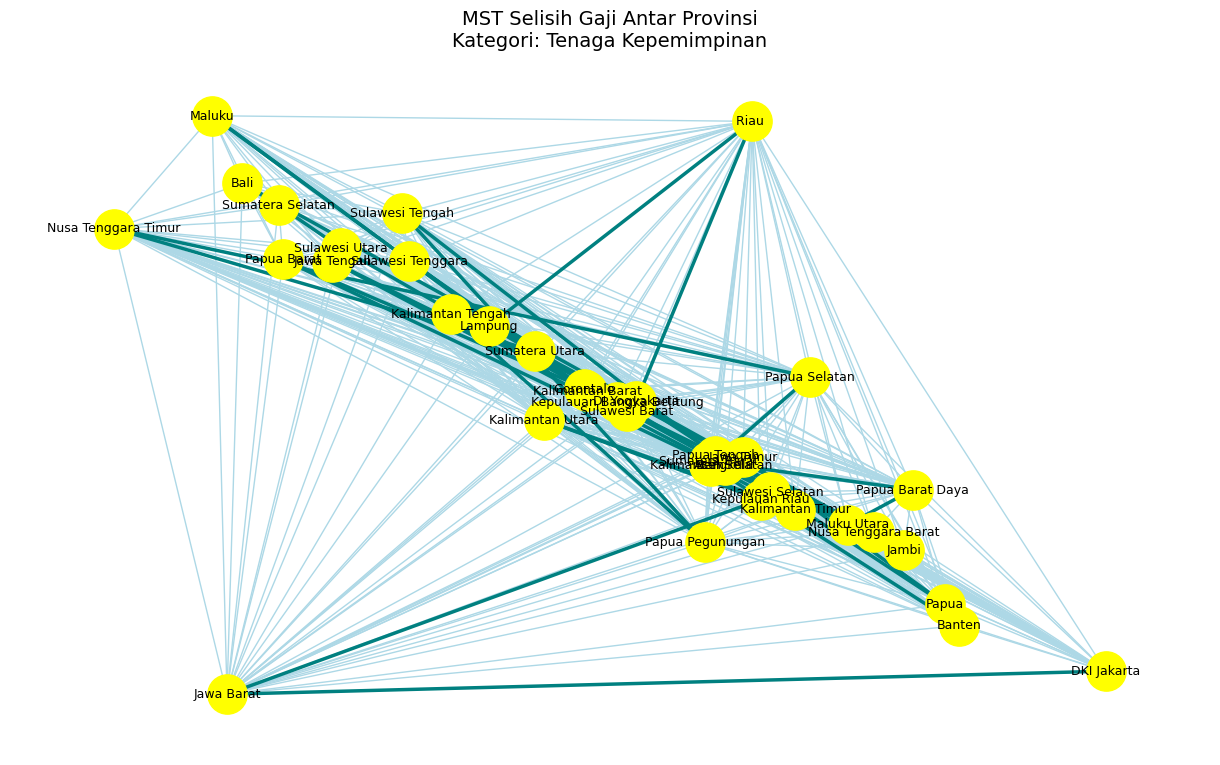


    MST untuk kategori: Tata usaha
Aceh -- Bengkulu, selisih gaji = 47939.56872196682
Aceh -- Jambi, selisih gaji = 56851.49055522261
Sumatera Utara -- Riau , selisih gaji = 2581.6594881257042
Sumatera Utara -- Sulawesi Selatan, selisih gaji = 99414.22469952656
Sumatera Barat -- Gorontalo, selisih gaji = 3153.6477374741808
Sumatera Barat -- Lampung, selisih gaji = 25630.144252966158
Riau  -- Papua Barat, selisih gaji = 5026.181580454577
Jambi -- Jawa Tengah, selisih gaji = 2556.4881380479783
Sumatera Selatan -- DI Yogyakarta, selisih gaji = 18739.31010910822
Sumatera Selatan -- Kalimantan Tengah, selisih gaji = 78973.4227310135
Bengkulu -- Sulawesi Tenggara, selisih gaji = 11397.820588615723
Lampung -- Sulawesi Tengah, selisih gaji = 24602.83397118328
Kepulauan Bangka Belitung -- Papua Pegunungan, selisih gaji = 20914.188190203626
Kepulauan Bangka Belitung -- Papua Barat Daya, selisih gaji = 164583.11118791532
Kepulauan Riau -- Jawa Barat, selisih gaji = 221706.0158073837
Kepulauan Ri

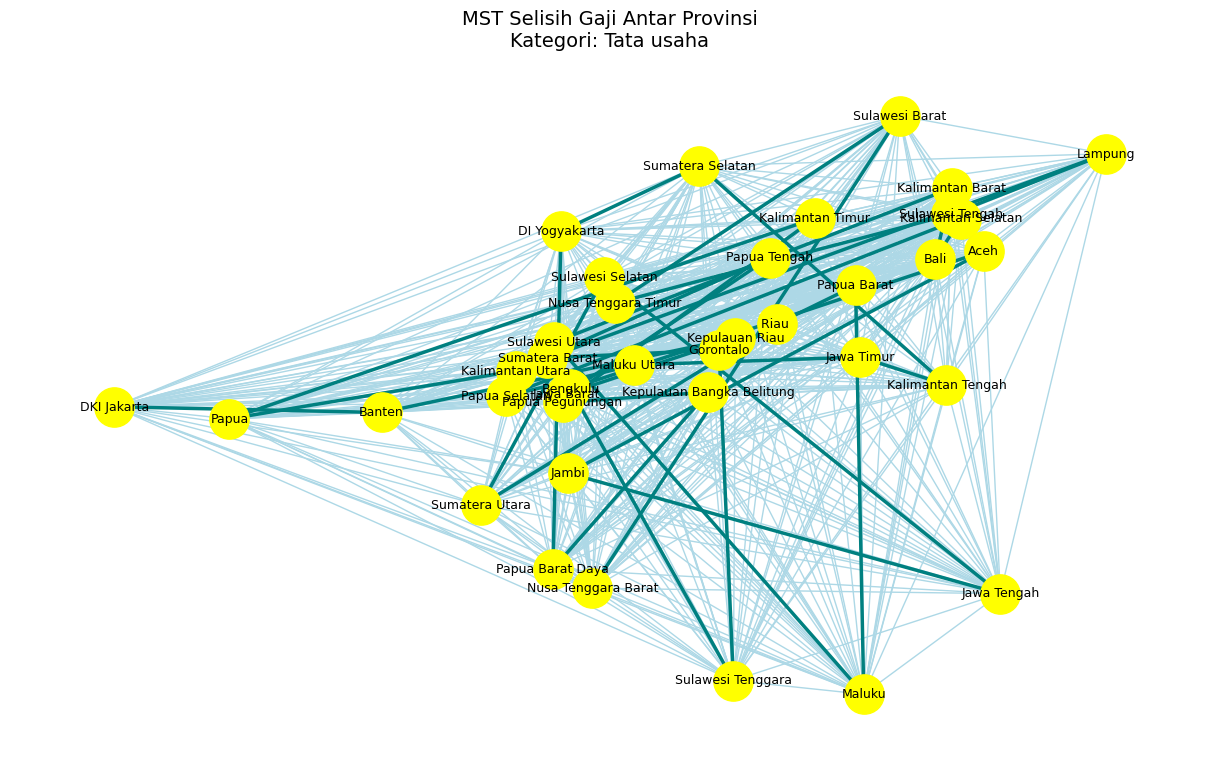


    MST untuk kategori: Penjualan
Aceh -- Sulawesi Tengah, selisih gaji = 7839.55163759971
Aceh -- Bengkulu, selisih gaji = 20028.805596980266
Sumatera Utara -- Sulawesi Selatan, selisih gaji = 4022.3985729129054
Sumatera Utara -- Sulawesi Tenggara, selisih gaji = 23759.539553294424
Sumatera Barat -- Sumatera Selatan, selisih gaji = 27662.40748573793
Sumatera Barat -- Riau , selisih gaji = 34337.129813760985
Riau  -- Kalimantan Tengah, selisih gaji = 9842.454542953521
Jambi -- Jawa Tengah, selisih gaji = 13505.544097130653
Jambi -- Bengkulu, selisih gaji = 18176.468736022245
Sumatera Selatan -- Lampung, selisih gaji = 15486.284952509683
Lampung -- Papua Barat, selisih gaji = 5106.729339576792
Kepulauan Bangka Belitung -- Maluku Utara, selisih gaji = 63261.729004479945
Kepulauan Bangka Belitung -- Kalimantan Utara, selisih gaji = 85092.16534064664
Kepulauan Riau -- Banten, selisih gaji = 383305.06323640374
Kepulauan Riau -- Papua, selisih gaji = 385243.7228242536
DKI Jakarta -- Banten,

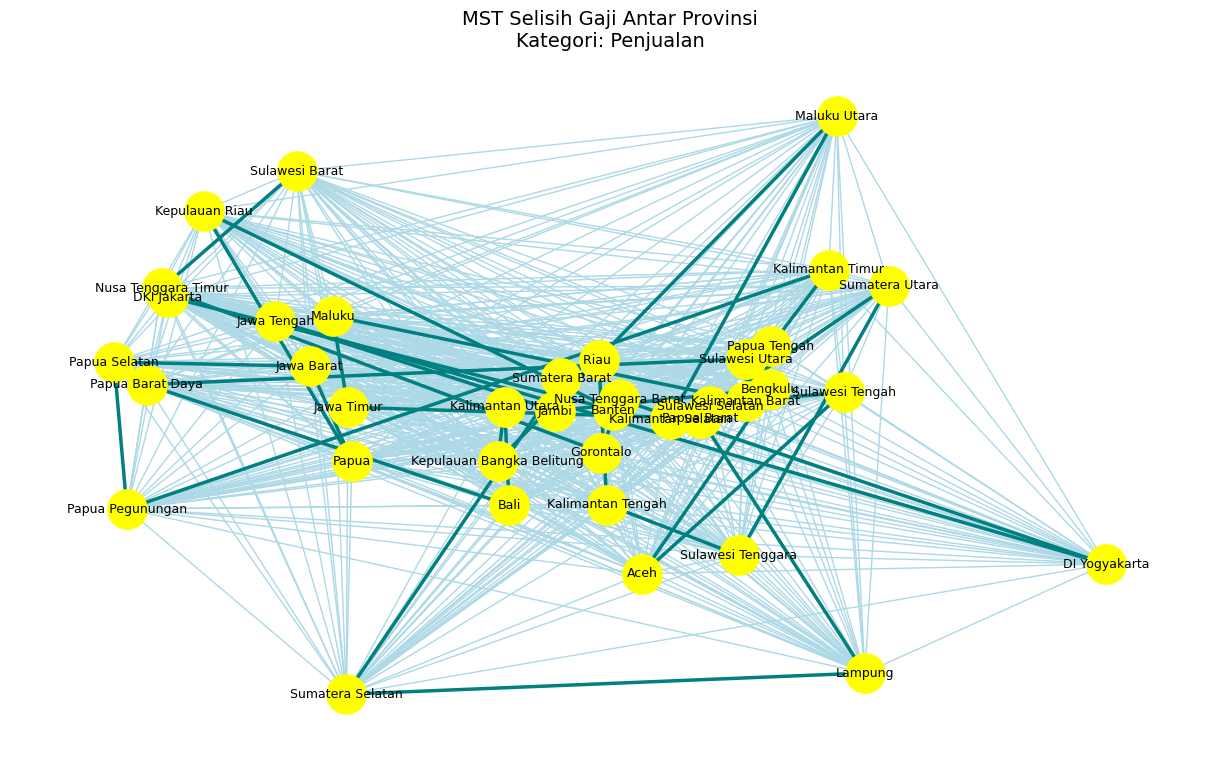


    MST untuk kategori: Jasa
Aceh -- Kalimantan Selatan, selisih gaji = 3635.785482833162
Aceh -- Sulawesi Tengah, selisih gaji = 40888.59062336944
Sumatera Utara -- Jawa Timur, selisih gaji = 6576.269687325228
Sumatera Utara -- Kalimantan Barat, selisih gaji = 77825.40225785458
Sumatera Barat -- Kepulauan Bangka Belitung, selisih gaji = 38984.92106988607
Sumatera Barat -- Jambi, selisih gaji = 120604.55682485085
Riau  -- Sulawesi Barat, selisih gaji = 18136.62455752073
Riau  -- Kepulauan Bangka Belitung, selisih gaji = 57877.67975829542
Jambi -- Maluku Utara, selisih gaji = 57818.11437044339
Sumatera Selatan -- Kalimantan Selatan, selisih gaji = 3786.729142352706
Sumatera Selatan -- Sulawesi Tenggara, selisih gaji = 33169.133566721575
Bengkulu -- Nusa Tenggara Timur, selisih gaji = 12273.200509987539
Bengkulu -- Jawa Tengah, selisih gaji = 21782.124278154457
Lampung -- Gorontalo, selisih gaji = 28722.581424121512
Lampung -- Nusa Tenggara Barat, selisih gaji = 166125.3224728685
Kepula

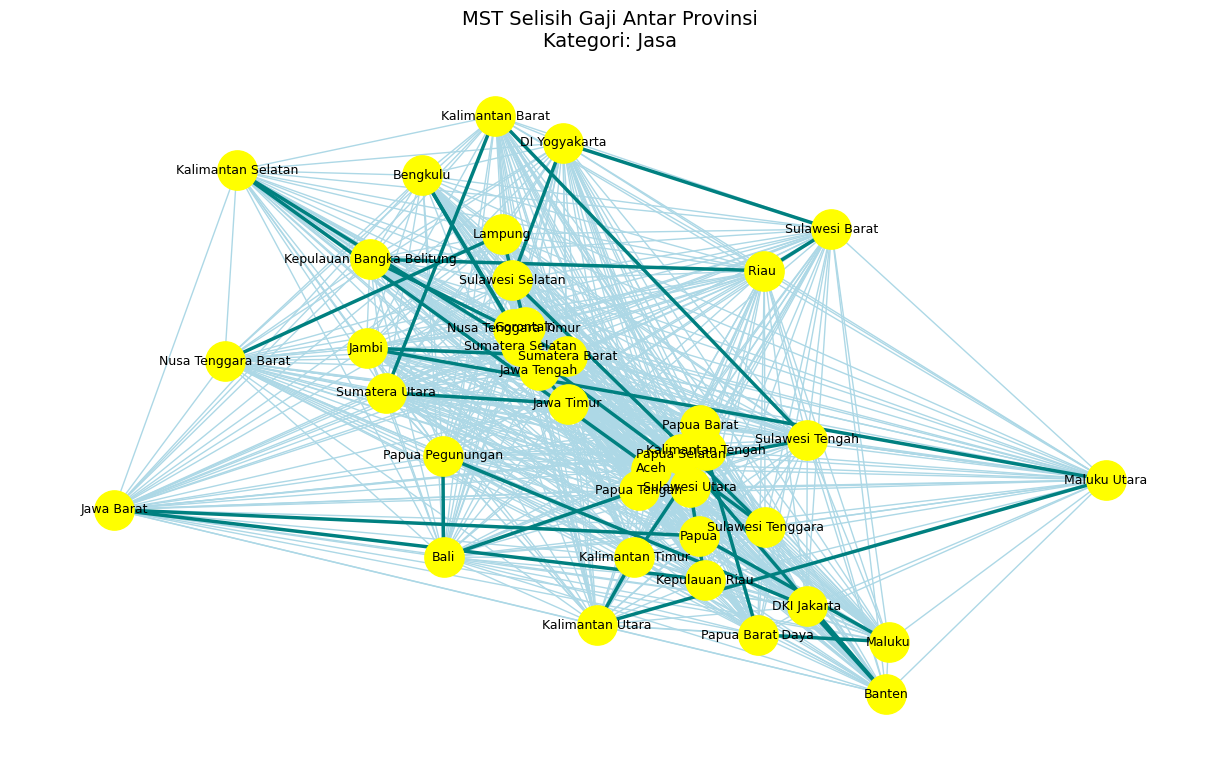


    MST untuk kategori: Pertanian 
Aceh -- Maluku, selisih gaji = 9488.38307795301
Aceh -- Kalimantan Utara, selisih gaji = 23911.727533252444
Sumatera Utara -- Kalimantan Selatan, selisih gaji = 25240.112496633083
Sumatera Utara -- Kalimantan Barat, selisih gaji = 34732.703352318145
Sumatera Barat -- Sulawesi Barat, selisih gaji = 4582.607912089676
Sumatera Barat -- Bali, selisih gaji = 31595.46327707451
Riau  -- Sulawesi Utara, selisih gaji = 2482.300121755805
Riau  -- DKI Jakarta, selisih gaji = 23015.978998797946
Jambi -- Sulawesi Barat, selisih gaji = 4303.438134155236
Jambi -- Lampung, selisih gaji = 46694.66629500268
Sumatera Selatan -- Sulawesi Selatan, selisih gaji = 6354.377156979172
Sumatera Selatan -- Sulawesi Tengah, selisih gaji = 86686.06123642437
Bengkulu -- Sulawesi Tengah, selisih gaji = 18936.05591640575
Bengkulu -- Jawa Tengah, selisih gaji = 20190.053133159876
Lampung -- Sulawesi Tenggara, selisih gaji = 58507.47663239995
Kepulauan Bangka Belitung -- Sulawesi Utar

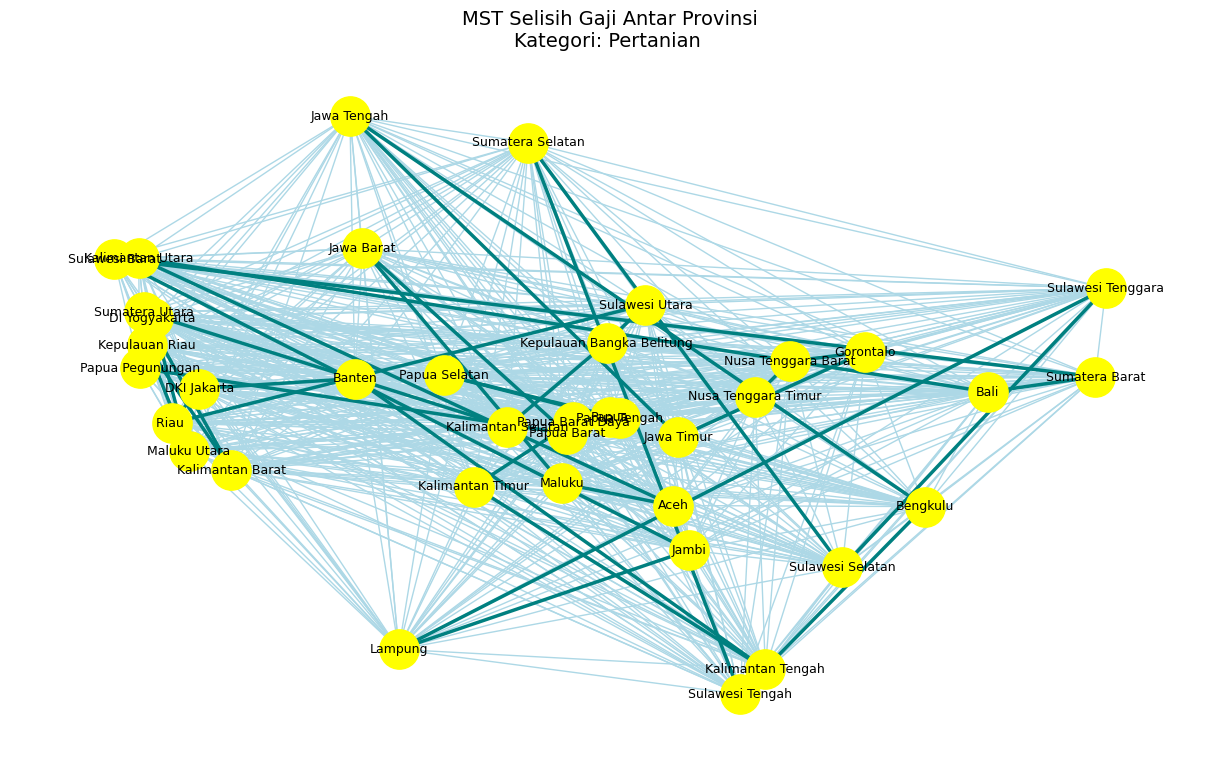


    MST untuk kategori: Pekerja Kasar
Aceh -- Jawa Tengah, selisih gaji = 59827.224766431376
Aceh -- Sumatera Barat, selisih gaji = 69589.73630503612
Sumatera Utara -- Sulawesi Selatan, selisih gaji = 37078.09888148215
Sumatera Utara -- Sulawesi Tengah, selisih gaji = 87953.4482338219
Sumatera Barat -- Maluku, selisih gaji = 36151.00508041028
Riau  -- Kalimantan Tengah, selisih gaji = 1801.3931450149976
Riau  -- Bali, selisih gaji = 144659.15538629238
Jambi -- Kalimantan Barat, selisih gaji = 35516.086598630995
Jambi -- Kepulauan Bangka Belitung, selisih gaji = 103552.83640223881
Sumatera Selatan -- Kepulauan Bangka Belitung, selisih gaji = 30398.588139252737
Sumatera Selatan -- Papua Barat, selisih gaji = 99826.15320920665
Bengkulu -- Lampung, selisih gaji = 30483.25013321312
Bengkulu -- Jawa Timur, selisih gaji = 151804.44107568497
Lampung -- Maluku, selisih gaji = 22011.399578077253
Kepulauan Riau -- Kalimantan Timur, selisih gaji = 93693.33888755087
Kepulauan Riau -- Papua Tengah,

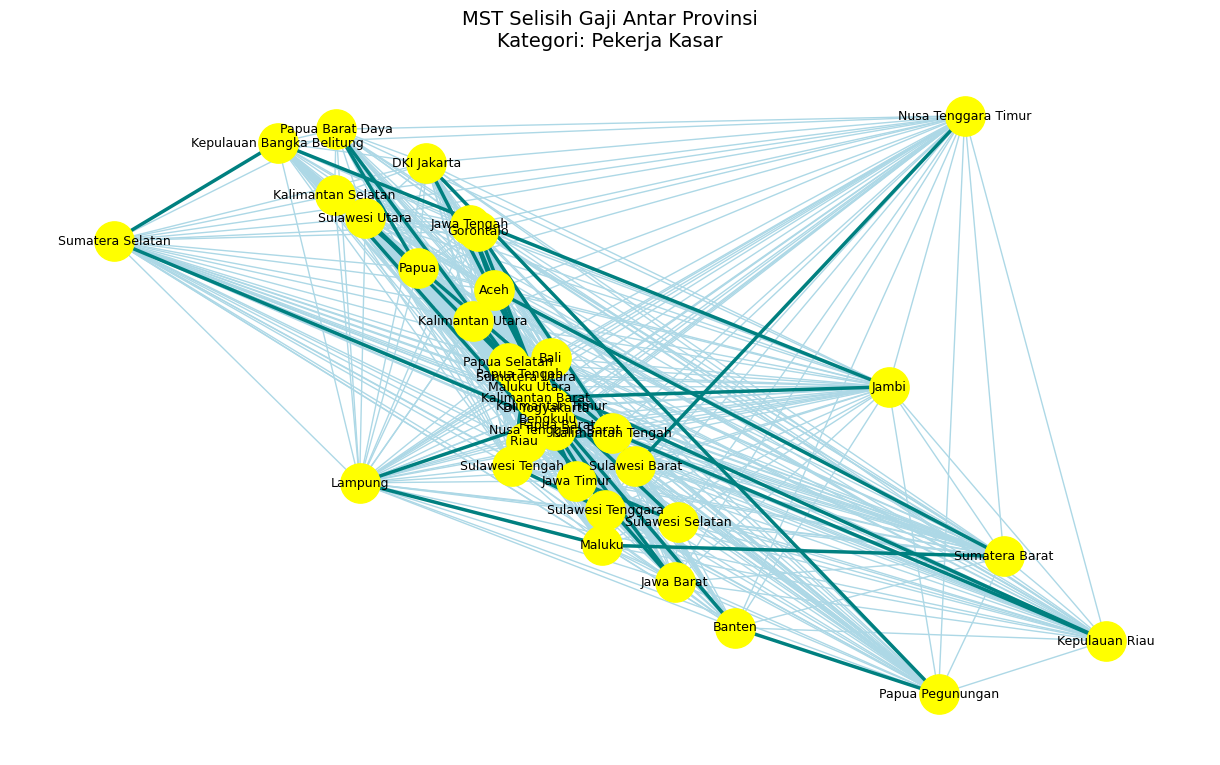


Selesai menghitung dan memvisualisasikan MST untuk seluruh kategori pekerjaan.


In [269]:
import pandas as pd
import itertools
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# 1. Baca file Excel
# ============================================================
df = pd.read_excel("Gaji.xlsx")

# Ambil semua kolom kategori (selain Provinsi)
kategori_list = [col for col in df.columns if col != "Provinsi"]

print("Kategori pekerjaan terdeteksi:", kategori_list)

# ============================================================
# 2. Loop otomatis untuk setiap kategori pekerjaan
# ============================================================
for kategori in kategori_list:
    print("\n======================================")
    print(f"    MST untuk kategori: {kategori}")
    print("======================================")

    # gaji per provinsi pada kategori tersebut
    gaji_dict = dict(zip(df["Provinsi"], df[kategori]))

    # ============================================================
    # 3. Bangun Graph (node = provinsi, edge = selisih gaji)
    # ============================================================
    G = nx.Graph()
    G.add_nodes_from(gaji_dict.keys())

    # Tambahkan edge antar provinsi
    for (prov1, g1), (prov2, g2) in itertools.combinations(gaji_dict.items(), 2):
        G.add_edge(prov1, prov2, weight=abs(g1 - g2))

    # ============================================================
    # 4. Minimum Spanning Tree (MST)
    # ============================================================
    mst = nx.minimum_spanning_tree(G)

    # Cetak MST
    for u, v, w in mst.edges(data=True):
        print(f"{u} -- {v}, selisih gaji = {w['weight']}")

    # ============================================================
    # 5. Visualisasi Graph + MST
    # ============================================================
    plt.figure(figsize=(12, 7))
    pos = nx.spring_layout(G, seed=42)

    # Graph lengkap (abu-abu)
    nx.draw(
        G, pos,
        with_labels=True,
        node_color="yellow",
        edge_color="lightblue",
        font_size=9,
        node_size=800
    )

    # MST (merah)
    nx.draw_networkx_edges(
        mst, pos,
        edge_color="teal",
        width=2.5
    )

    plt.title(f"MST Selisih Gaji Antar Provinsi\nKategori: {kategori}", fontsize=14)
    plt.show()

print("\nSelesai menghitung dan memvisualisasikan MST untuk seluruh kategori pekerjaan.")

In [59]:
# =============================
# 6. TEORI BILANGAN BULAT
# =============================
def is_prime(n):
    n = int(n)
    if n < 2: return False
    i = 2
    while i * i <= n:
        if n % i == 0: return False
        i += 1
    return True

df["Pekerja Kasar_rounded"] = (df["Pekerja Kasar"].astype(int) // 1000).astype(int)
df["Pekerja Kasar_is_prime"] = df["Pekerja Kasar_rounded"].apply(is_prime)
df["FPB_Pertanian _Pekerja Kasar"] = df.apply(lambda r: gcd(int(r["Pertanian "]), int(r["Pekerja Kasar"])), axis=1)
df["mod3_pro"] = df["Industri"].astype(int) % 3

print(df)

                     Provinsi      Industri  Tenaga Kepemimpinan  \
0                        Aceh  2.849632e+06         3.598366e+06   
1              Sumatera Utara  3.126435e+06         4.364995e+06   
2              Sumatera Barat  3.318996e+06         5.332000e+06   
3                       Riau   3.755738e+06         5.512338e+06   
4                       Jambi  3.468120e+06         4.819097e+06   
5            Sumatera Selatan  3.375189e+06         4.803239e+06   
6                    Bengkulu  3.359707e+06         5.139315e+06   
7                     Lampung  2.703824e+06         5.491139e+06   
8   Kepulauan Bangka Belitung  4.261173e+06         5.420088e+06   
9              Kepulauan Riau  5.813965e+06         8.950320e+06   
10                DKI Jakarta  8.551507e+06         1.432983e+07   
11                 Jawa Barat  4.493547e+06         1.062685e+07   
12                Jawa Tengah  3.229099e+06         5.445938e+06   
13              DI Yogyakarta  4.347247e+06     

                     Provinsi      Industri  Tenaga Kepemimpinan  \
0                        Aceh  2.849632e+06         3.598366e+06   
1              Sumatera Utara  3.126435e+06         4.364995e+06   
2              Sumatera Barat  3.318996e+06         5.332000e+06   
3                       Riau   3.755738e+06         5.512338e+06   
4                       Jambi  3.468120e+06         4.819097e+06   
5            Sumatera Selatan  3.375189e+06         4.803239e+06   
6                    Bengkulu  3.359707e+06         5.139315e+06   
7                     Lampung  2.703824e+06         5.491139e+06   
8   Kepulauan Bangka Belitung  4.261173e+06         5.420088e+06   
9              Kepulauan Riau  5.813965e+06         8.950320e+06   
10                DKI Jakarta  8.551507e+06         1.432983e+07   
11                 Jawa Barat  4.493547e+06         1.062685e+07   
12                Jawa Tengah  3.229099e+06         5.445938e+06   
13              DI Yogyakarta  4.347247e+06     

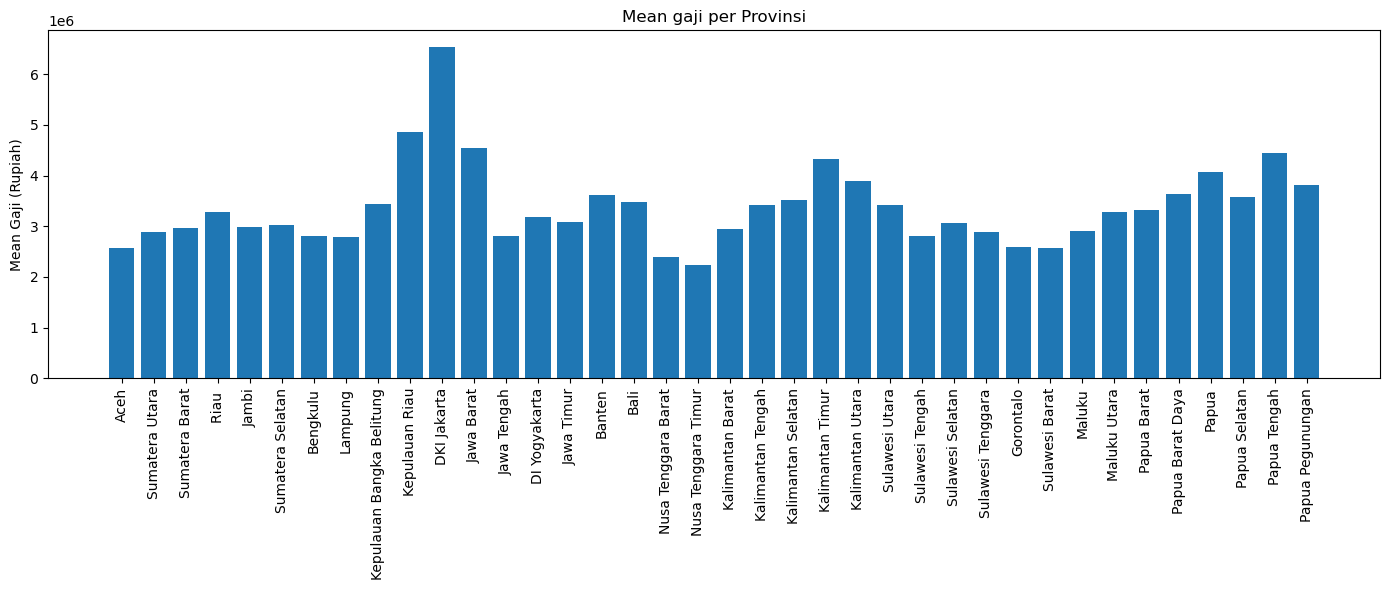

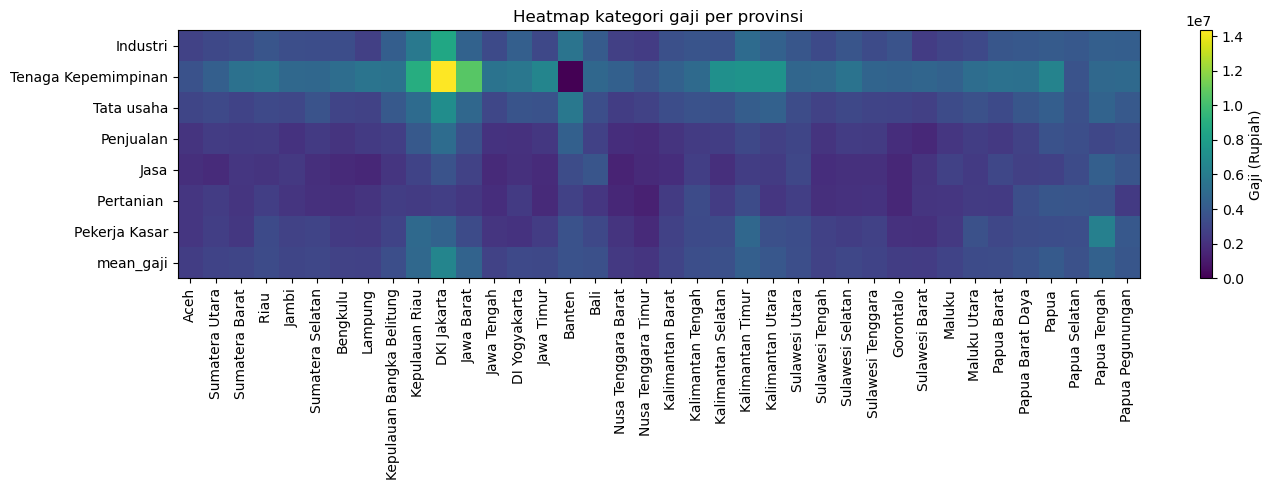

In [62]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from math import gcd

# =============================
# 1. BACA DATA
# =============================
df = pd.read_excel("Gaji.xlsx")

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# =============================
# 2. OPERASI LOGIKA
# =============================
logic1_df = df[
    (df["Industri"] > 5_000_000) &
    (df["Pekerja Kasar"] > 3_000_000)
][["Provinsi", "Industri", "Pekerja Kasar"]]

logic2_df = df[
    (df["Jasa"] < 2_000_000) |
    (df["Pertanian "] < 2_000_000)
][["Provinsi", "Jasa", "Pertanian "]]

# =============================
# 3. OPERASI HIMPUNAN
# =============================
avg_pro = df["Industri"].mean()
avg_buruh = df["Pekerja Kasar"].mean()

A = set(df[df["Industri"] > avg_pro]["Provinsi"])
B = set(df[df["Pekerja Kasar"] > avg_pro]["Provinsi"])

union_set = A | B
intersection_set = A & B
A_minus_B = A - B
B_minus_A = B - A

df["mean_gaji"] = df.iloc[:,1:].mean(axis=1)
threshold = 500_000
for i in range(len(df)):
    for j in range(i+1, len(df)):
        if abs(df.loc[i,"mean_gaji"] - df.loc[j,"mean_gaji"]) < threshold:
            G.add_edge(df.loc[i,"Provinsi"], df.loc[j,"Provinsi"])

# =============================
# 6. TEORI BILANGAN BULAT
# =============================
def is_prime(n):
    n = int(n)
    if n < 2: return False
    i = 2
    while i * i <= n:
        if n % i == 0: return False
        i += 1
    return True

df["Pekerja Kasar_rounded"] = (df["Pekerja Kasar"].astype(int) // 1000).astype(int)
df["Pekerja Kasar_is_prime"] = df["Pekerja Kasar_rounded"].apply(is_prime)
df["FPB_Pertanian _Pekerja Kasar"] = df.apply(lambda r: gcd(int(r["Pertanian "]), int(r["Pekerja Kasar"])), axis=1)
df["mod3_pro"] = df["Industri"].astype(int) % 3


# =============================
# 7. VISUALISASI
# =============================
# Bar plot mean gaji per provinsi
plt.figure(figsize=(14,6))
plt.bar(df["Provinsi"], df["mean_gaji"])
plt.xticks(rotation=90)
plt.ylabel("Mean Gaji (Rupiah)")
plt.title("Mean gaji per Provinsi")
plt.tight_layout()
plt.show()

# Heatmap kategori gaji
categories = df.columns[1:9]  # semua kategori gaji
mat = df[categories].values.T
plt.figure(figsize=(14,5))
plt.imshow(mat, aspect='auto')
plt.yticks(range(len(categories)), categories)
plt.xticks(range(len(df)), df["Provinsi"], rotation=90)
plt.colorbar(label="Gaji (Rupiah)")
plt.title("Heatmap kategori gaji per provinsi")
plt.tight_layout()
plt.show()

In [277]:
import pandas as pd
import itertools
import math

# ============================
# 1. BACA DATA
# ============================
df = pd.read_excel("Gaji.xlsx")

provinsi = df["Provinsi"].tolist()
kategori = [col for col in df.columns if col != "Provinsi"]

print("Jumlah provinsi:", len(provinsi))
print("Kategori pekerjaan:", kategori)


# ============================================================
# 2. KOMBINASI PROVINSI (nC2, nC3, ...)
# ============================================================
def kombinasi_provinsi(r):
    combs = list(itertools.combinations(provinsi, r))
    print(f"\n=== Kombinasi Provinsi (nCr={r}) jumlah={len(combs)} ===")
    for c in combs[:20]:  # batasi 20 biar tidak memenuhi layar
        print(c)
    return combs

# Contoh
kombinasi_provinsi(2)
kombinasi_provinsi(3)


# ============================================================
# 3. SELISIH GAJI UNTUK SETIAP KOMBINASI PROVINSI (PAIRWISE)
# ============================================================
def selisih_gaji_pairwise():
    results = []

    for (prov1, prov2) in itertools.combinations(provinsi, 2):
        row1 = df[df["Provinsi"] == prov1].iloc[0]
        row2 = df[df["Provinsi"] == prov2].iloc[0]

        for cat in kategori:
            diff = abs(row1[cat] - row2[cat])
            results.append([prov1, prov2, cat, diff])

    result_df = pd.DataFrame(results, columns=["Provinsi1", "Provinsi2", "Kategori", "Selisih"])
    print("\n=== Selisih gaji pairwise (5 teratas) ===")
    print(result_df.head())

    return result_df

df_selisih = selisih_gaji_pairwise()


Jumlah provinsi: 38
Kategori pekerjaan: ['Industri', 'Tenaga Kepemimpinan', 'Tata usaha', 'Penjualan', 'Jasa', 'Pertanian ', 'Pekerja Kasar']

=== Kombinasi Provinsi (nCr=2) jumlah=703 ===
('Aceh', 'Sumatera Utara')
('Aceh', 'Sumatera Barat')
('Aceh', 'Riau ')
('Aceh', 'Jambi')
('Aceh', 'Sumatera Selatan')
('Aceh', 'Bengkulu')
('Aceh', 'Lampung')
('Aceh', 'Kepulauan Bangka Belitung')
('Aceh', 'Kepulauan Riau')
('Aceh', 'DKI Jakarta')
('Aceh', 'Jawa Barat')
('Aceh', 'Jawa Tengah')
('Aceh', 'DI Yogyakarta')
('Aceh', 'Jawa Timur')
('Aceh', 'Banten')
('Aceh', 'Bali')
('Aceh', 'Nusa Tenggara Barat')
('Aceh', 'Nusa Tenggara Timur')
('Aceh', 'Kalimantan Barat')
('Aceh', 'Kalimantan Tengah')

=== Kombinasi Provinsi (nCr=3) jumlah=8436 ===
('Aceh', 'Sumatera Utara', 'Sumatera Barat')
('Aceh', 'Sumatera Utara', 'Riau ')
('Aceh', 'Sumatera Utara', 'Jambi')
('Aceh', 'Sumatera Utara', 'Sumatera Selatan')
('Aceh', 'Sumatera Utara', 'Bengkulu')
('Aceh', 'Sumatera Utara', 'Lampung')
('Aceh', 'Sumatera

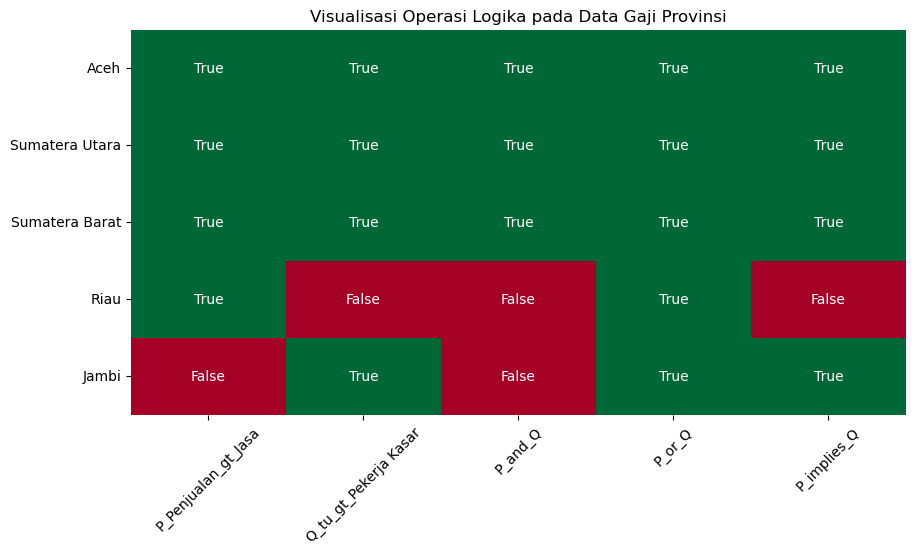

In [255]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = {
    "Provinsi": ["Aceh", "Sumatera Utara", "Sumatera Barat", "Riau", "Jambi"],
    "P_Penjualan_gt_Jasa": [True, True, True, True, False],
    "Q_tu_gt_Pekerja Kasar": [True, True, True, False, True],
    "P_and_Q": [True, True, True, False, False],
    "P_or_Q": [True, True, True, True, True],
    "P_implies_Q": [True, True, True, False, True]
}

df_logic = pd.DataFrame(data)

# Ubah True/False menjadi angka untuk heatmap
df_numeric = df_logic.drop(columns=["Provinsi"]).astype(int)

plt.figure(figsize=(10,5))
sns.heatmap(df_numeric, annot=df_logic.drop(columns=["Provinsi"]), fmt='', cmap='RdYlGn', cbar=False)
plt.title("Visualisasi Operasi Logika pada Data Gaji Provinsi")
plt.yticks(ticks=[0.5,1.5,2.5,3.5,4.5], labels=df_logic['Provinsi'], rotation=0)
plt.xticks(rotation=45)
plt.show()


Kategori pekerjaan terdeteksi: ['Industri', 'Tenaga Kepemimpinan', 'Tata usaha', 'Penjualan', 'Jasa', 'Pertanian ', 'Pekerja Kasar']

    MST untuk kategori: Industri
Aceh -- Maluku, selisih gaji = 76509.94140361436
Aceh -- Lampung, selisih gaji = 145807.745257074
Sumatera Utara -- Jawa Timur, selisih gaji = 36333.129343240056
Sumatera Utara -- Maluku Utara, selisih gaji = 52934.787821244914
Sumatera Barat -- Bengkulu, selisih gaji = 40710.10977271106
Sumatera Barat -- Sulawesi Tenggara, selisih gaji = 55238.59860102739
Riau  -- Sulawesi Selatan, selisih gaji = 19951.16434142785
Riau  -- Kalimantan Tengah, selisih gaji = 51436.919882191345
Jambi -- Kalimantan Barat, selisih gaji = 33336.5606428287
Jambi -- Sumatera Selatan, selisih gaji = 92930.21713005425
Sumatera Selatan -- Bengkulu, selisih gaji = 15482.749343095347
Lampung -- Nusa Tenggara Barat, selisih gaji = 3930.751297786366
Kepulauan Bangka Belitung -- Papua Pegunungan, selisih gaji = 17966.612331927754
Kepulauan Bangka Belitu

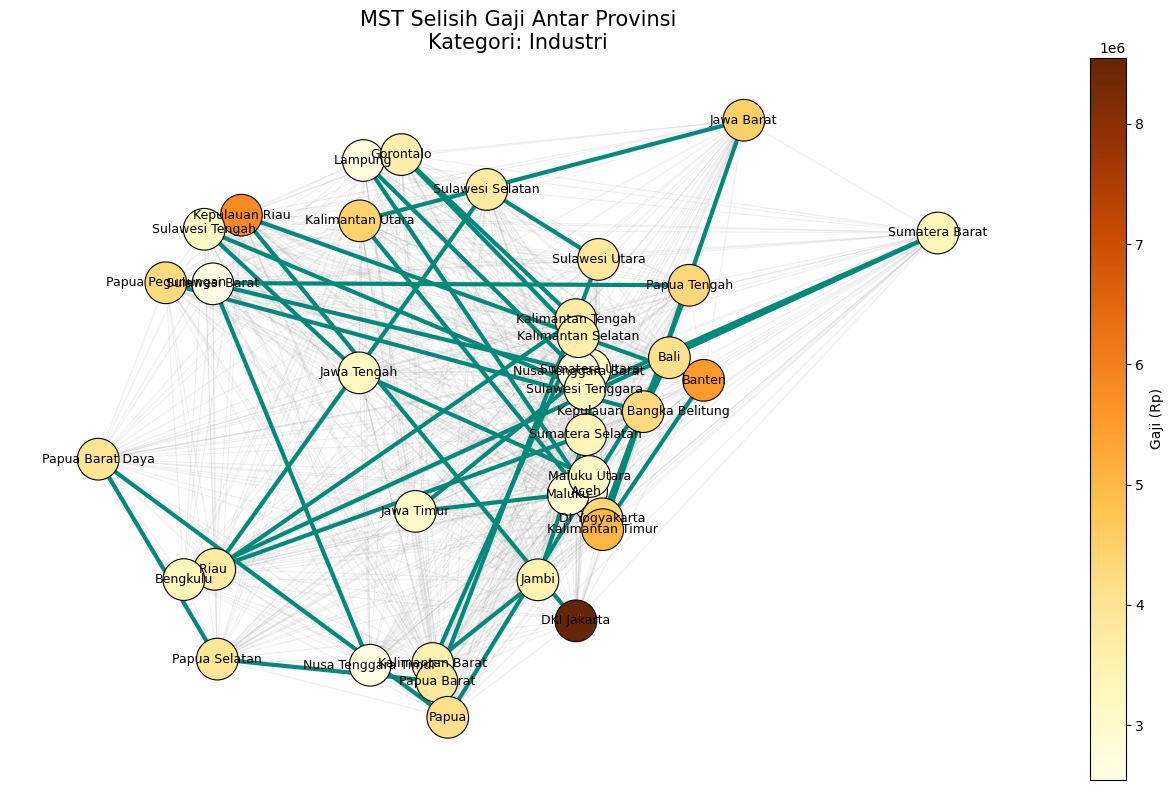


    MST untuk kategori: Tenaga Kepemimpinan
Aceh -- Papua Selatan, selisih gaji = 90972.57549125794
Aceh -- Banten, selisih gaji = 3598366.0565543408
Sumatera Utara -- Nusa Tenggara Barat, selisih gaji = 54543.419326063246
Sumatera Utara -- Nusa Tenggara Timur, selisih gaji = 561111.0005511148
Sumatera Barat -- Papua Barat Daya, selisih gaji = 18713.12452737149
Sumatera Barat -- Papua Barat, selisih gaji = 39034.38908592146
Riau  -- Lampung, selisih gaji = 21198.640876485966
Riau  -- DI Yogyakarta, selisih gaji = 181544.54354337603
Jambi -- Bali, selisih gaji = 5272.363476860337
Jambi -- Papua Tengah, selisih gaji = 27616.986091880128
Sumatera Selatan -- Bali, selisih gaji = 10585.20207183715
Sumatera Selatan -- Sulawesi Utara, selisih gaji = 68333.32961188443
Bengkulu -- Maluku Utara, selisih gaji = 9156.471570191905
Bengkulu -- Kalimantan Tengah, selisih gaji = 163538.74896368757
Lampung -- Sulawesi Selatan, selisih gaji = 21268.933386275545
Kepulauan Bangka Belitung -- Jawa Tengah,

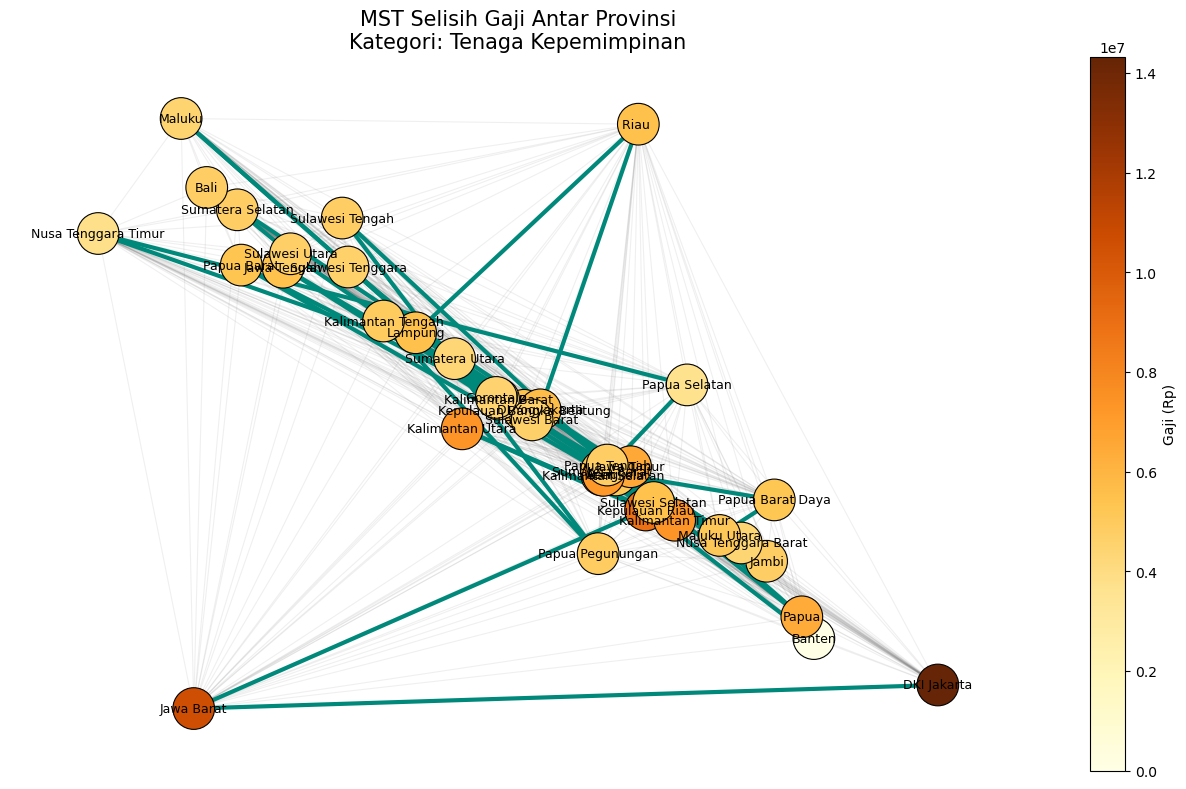


    MST untuk kategori: Tata usaha
Aceh -- Bengkulu, selisih gaji = 47939.56872196682
Aceh -- Jambi, selisih gaji = 56851.49055522261
Sumatera Utara -- Riau , selisih gaji = 2581.6594881257042
Sumatera Utara -- Sulawesi Selatan, selisih gaji = 99414.22469952656
Sumatera Barat -- Gorontalo, selisih gaji = 3153.6477374741808
Sumatera Barat -- Lampung, selisih gaji = 25630.144252966158
Riau  -- Papua Barat, selisih gaji = 5026.181580454577
Jambi -- Jawa Tengah, selisih gaji = 2556.4881380479783
Sumatera Selatan -- DI Yogyakarta, selisih gaji = 18739.31010910822
Sumatera Selatan -- Kalimantan Tengah, selisih gaji = 78973.4227310135
Bengkulu -- Sulawesi Tenggara, selisih gaji = 11397.820588615723
Lampung -- Sulawesi Tengah, selisih gaji = 24602.83397118328
Kepulauan Bangka Belitung -- Papua Pegunungan, selisih gaji = 20914.188190203626
Kepulauan Bangka Belitung -- Papua Barat Daya, selisih gaji = 164583.11118791532
Kepulauan Riau -- Jawa Barat, selisih gaji = 221706.0158073837
Kepulauan Ri

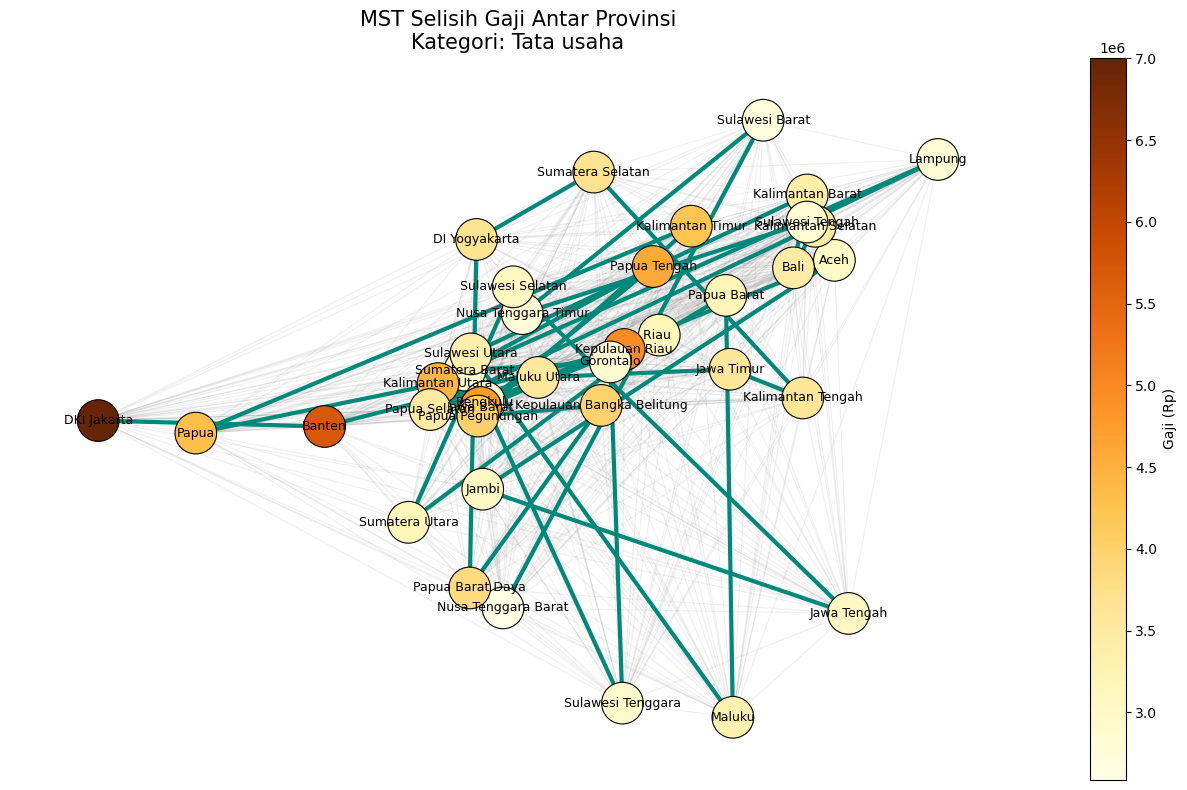


    MST untuk kategori: Penjualan
Aceh -- Sulawesi Tengah, selisih gaji = 7839.55163759971
Aceh -- Bengkulu, selisih gaji = 20028.805596980266
Sumatera Utara -- Sulawesi Selatan, selisih gaji = 4022.3985729129054
Sumatera Utara -- Sulawesi Tenggara, selisih gaji = 23759.539553294424
Sumatera Barat -- Sumatera Selatan, selisih gaji = 27662.40748573793
Sumatera Barat -- Riau , selisih gaji = 34337.129813760985
Riau  -- Kalimantan Tengah, selisih gaji = 9842.454542953521
Jambi -- Jawa Tengah, selisih gaji = 13505.544097130653
Jambi -- Bengkulu, selisih gaji = 18176.468736022245
Sumatera Selatan -- Lampung, selisih gaji = 15486.284952509683
Lampung -- Papua Barat, selisih gaji = 5106.729339576792
Kepulauan Bangka Belitung -- Maluku Utara, selisih gaji = 63261.729004479945
Kepulauan Bangka Belitung -- Kalimantan Utara, selisih gaji = 85092.16534064664
Kepulauan Riau -- Banten, selisih gaji = 383305.06323640374
Kepulauan Riau -- Papua, selisih gaji = 385243.7228242536
DKI Jakarta -- Banten,

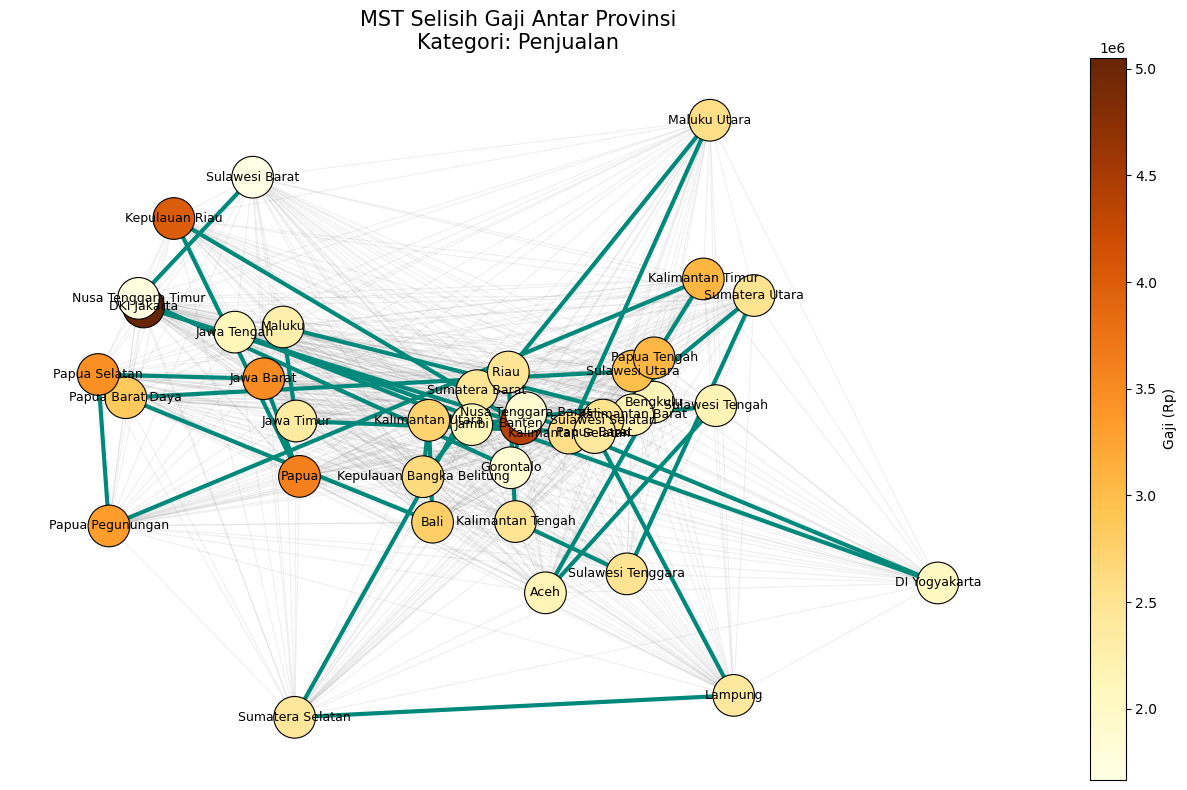


    MST untuk kategori: Jasa
Aceh -- Kalimantan Selatan, selisih gaji = 3635.785482833162
Aceh -- Sulawesi Tengah, selisih gaji = 40888.59062336944
Sumatera Utara -- Jawa Timur, selisih gaji = 6576.269687325228
Sumatera Utara -- Kalimantan Barat, selisih gaji = 77825.40225785458
Sumatera Barat -- Kepulauan Bangka Belitung, selisih gaji = 38984.92106988607
Sumatera Barat -- Jambi, selisih gaji = 120604.55682485085
Riau  -- Sulawesi Barat, selisih gaji = 18136.62455752073
Riau  -- Kepulauan Bangka Belitung, selisih gaji = 57877.67975829542
Jambi -- Maluku Utara, selisih gaji = 57818.11437044339
Sumatera Selatan -- Kalimantan Selatan, selisih gaji = 3786.729142352706
Sumatera Selatan -- Sulawesi Tenggara, selisih gaji = 33169.133566721575
Bengkulu -- Nusa Tenggara Timur, selisih gaji = 12273.200509987539
Bengkulu -- Jawa Tengah, selisih gaji = 21782.124278154457
Lampung -- Gorontalo, selisih gaji = 28722.581424121512
Lampung -- Nusa Tenggara Barat, selisih gaji = 166125.3224728685
Kepula

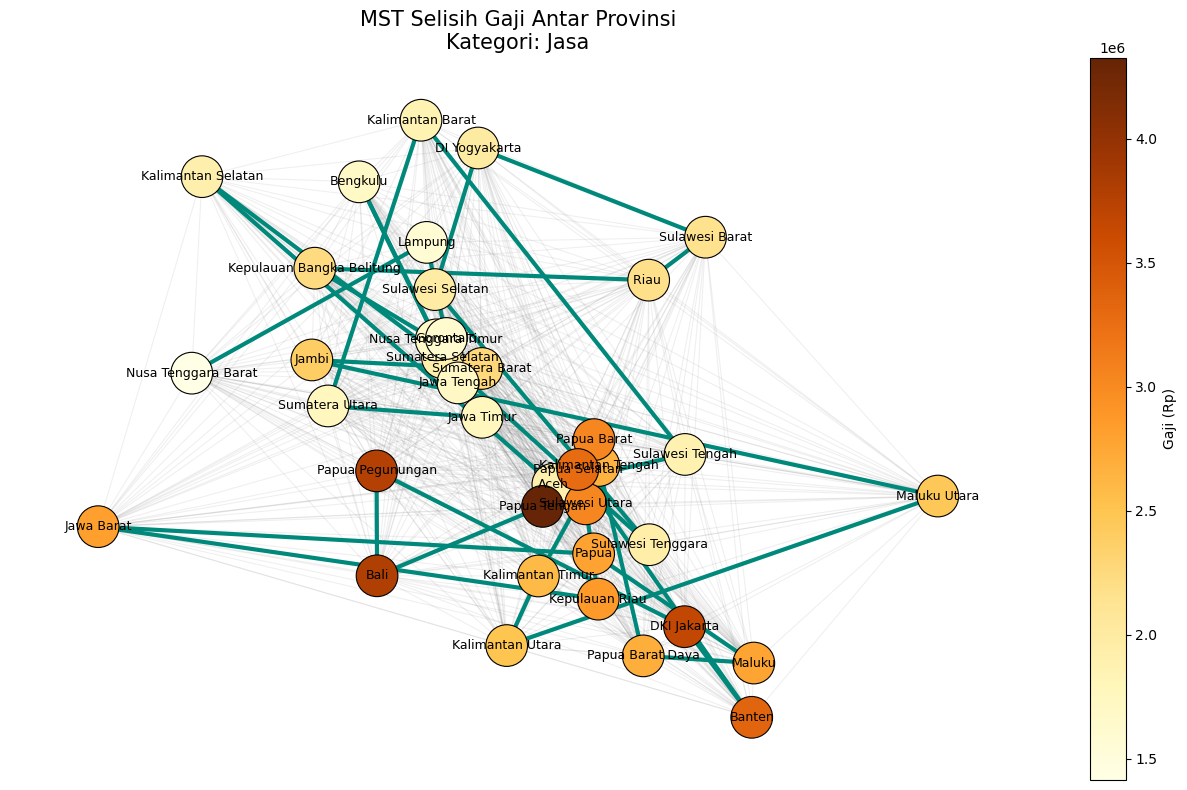


    MST untuk kategori: Pertanian 
Aceh -- Maluku, selisih gaji = 9488.38307795301
Aceh -- Kalimantan Utara, selisih gaji = 23911.727533252444
Sumatera Utara -- Kalimantan Selatan, selisih gaji = 25240.112496633083
Sumatera Utara -- Kalimantan Barat, selisih gaji = 34732.703352318145
Sumatera Barat -- Sulawesi Barat, selisih gaji = 4582.607912089676
Sumatera Barat -- Bali, selisih gaji = 31595.46327707451
Riau  -- Sulawesi Utara, selisih gaji = 2482.300121755805
Riau  -- DKI Jakarta, selisih gaji = 23015.978998797946
Jambi -- Sulawesi Barat, selisih gaji = 4303.438134155236
Jambi -- Lampung, selisih gaji = 46694.66629500268
Sumatera Selatan -- Sulawesi Selatan, selisih gaji = 6354.377156979172
Sumatera Selatan -- Sulawesi Tengah, selisih gaji = 86686.06123642437
Bengkulu -- Sulawesi Tengah, selisih gaji = 18936.05591640575
Bengkulu -- Jawa Tengah, selisih gaji = 20190.053133159876
Lampung -- Sulawesi Tenggara, selisih gaji = 58507.47663239995
Kepulauan Bangka Belitung -- Sulawesi Utar

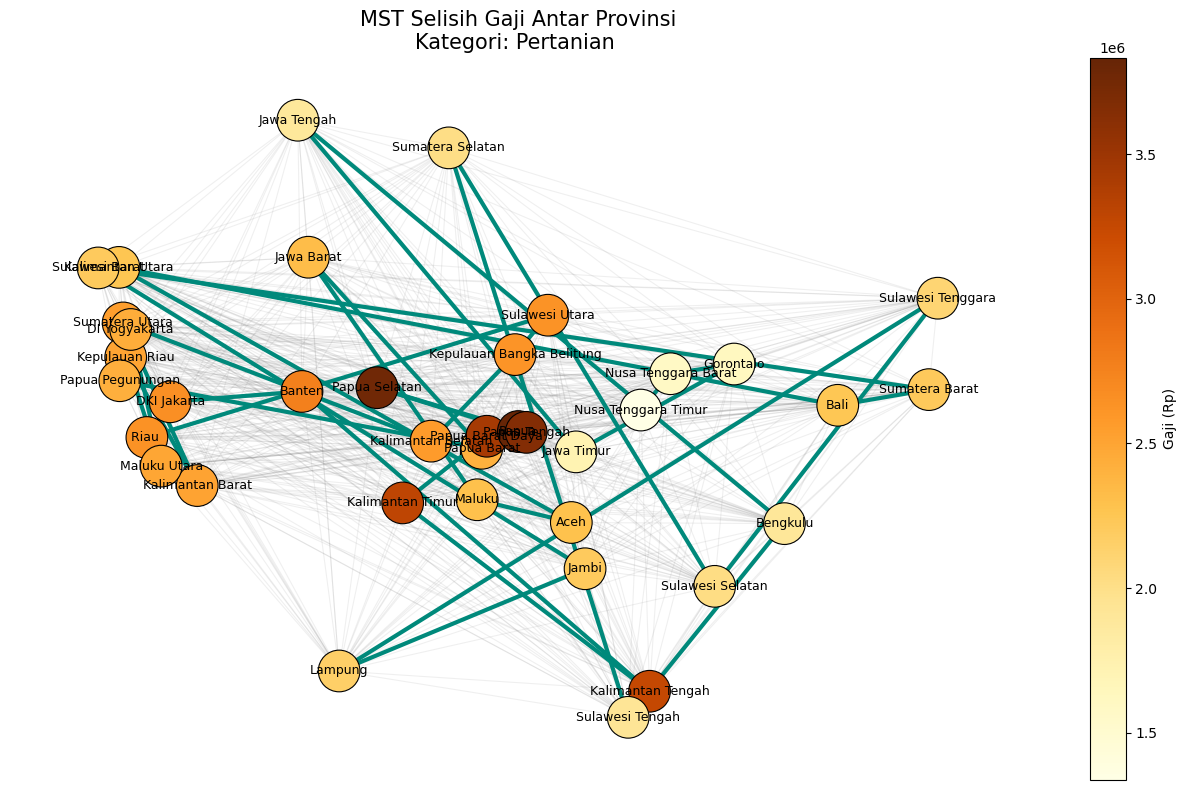


    MST untuk kategori: Pekerja Kasar
Aceh -- Jawa Tengah, selisih gaji = 59827.224766431376
Aceh -- Sumatera Barat, selisih gaji = 69589.73630503612
Sumatera Utara -- Sulawesi Selatan, selisih gaji = 37078.09888148215
Sumatera Utara -- Sulawesi Tengah, selisih gaji = 87953.4482338219
Sumatera Barat -- Maluku, selisih gaji = 36151.00508041028
Riau  -- Kalimantan Tengah, selisih gaji = 1801.3931450149976
Riau  -- Bali, selisih gaji = 144659.15538629238
Jambi -- Kalimantan Barat, selisih gaji = 35516.086598630995
Jambi -- Kepulauan Bangka Belitung, selisih gaji = 103552.83640223881
Sumatera Selatan -- Kepulauan Bangka Belitung, selisih gaji = 30398.588139252737
Sumatera Selatan -- Papua Barat, selisih gaji = 99826.15320920665
Bengkulu -- Lampung, selisih gaji = 30483.25013321312
Bengkulu -- Jawa Timur, selisih gaji = 151804.44107568497
Lampung -- Maluku, selisih gaji = 22011.399578077253
Kepulauan Riau -- Kalimantan Timur, selisih gaji = 93693.33888755087
Kepulauan Riau -- Papua Tengah,

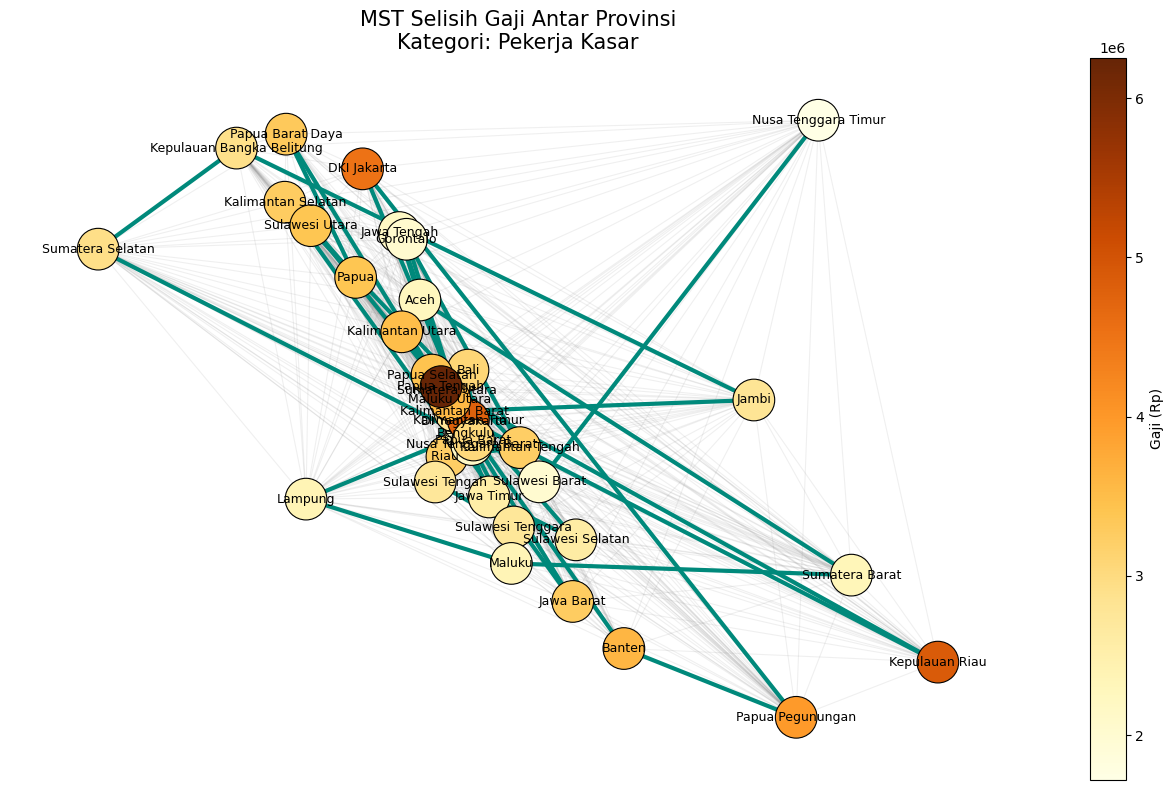


Selesai membuat semua graf MST.


In [275]:
import pandas as pd
import itertools
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# 1. Baca file Excel
# ============================================================
df = pd.read_excel("Gaji.xlsx")

# Ambil semua kolom kategori (selain Provinsi)
kategori_list = [col for col in df.columns if col != "Provinsi"]

print("Kategori pekerjaan terdeteksi:", kategori_list)

# ============================================================
# 2. Loop otomatis untuk setiap kategori pekerjaan
# ============================================================
for kategori in kategori_list:
    print("\n======================================")
    print(f"    MST untuk kategori: {kategori}")
    print("======================================")

    # gaji per provinsi pada kategori tersebut
    gaji_dict = dict(zip(df["Provinsi"], df[kategori]))

    # ============================================================
    # 3. Bangun Graph (node = provinsi, edge = selisih gaji)
    # ============================================================
    G = nx.Graph()
    G.add_nodes_from(gaji_dict.keys())

    for (prov1, g1), (prov2, g2) in itertools.combinations(gaji_dict.items(), 2):
        G.add_edge(prov1, prov2, weight=abs(g1 - g2))

    # ============================================================
    # 4. Minimum Spanning Tree (MST)
    # ============================================================
    mst = nx.minimum_spanning_tree(G)

    # Cetak MST
    for u, v, w in mst.edges(data=True):
        print(f"{u} -- {v}, selisih gaji = {w['weight']}")

    # ============================================================
    # 5. Visualisasi (lebih rapi & warna lebih cantik)
    # ============================================================
    plt.figure(figsize=(13, 8))

    # layout dipasang dari graph lengkap (agar stabil)
    pos = nx.spring_layout(G, seed=42)

    # warna node berdasarkan gaji → colormap
    gaji_values = list(gaji_dict.values())
    node_colors = [gaji_dict[p] for p in G.nodes()]

    # 5.1. Garis graph lengkap dibuat tipis & transparan
    nx.draw_networkx_edges(
        G, pos,
        alpha=0.12,
        width=0.8,
        edge_color="gray"
    )

    # 5.2. Garis MST dibuat tebal dan menonjol
    nx.draw_networkx_edges(
        mst, pos,
        edge_color="#00897b",   # hijau teal elegan
        width=3
    )

    # 5.3. Node dengan warna berdasarkan gaji (lebih informatif)
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=900,
        node_color=node_colors,
        cmap="YlOrBr",   # kuning → oranye → coklat
        edgecolors="black",
        linewidths=0.8
    )

    # 5.4. Label provinsi
    nx.draw_networkx_labels(G, pos, font_size=9)

    # Tambah colorbar
    cbar = plt.colorbar(nodes)
    cbar.set_label("Gaji (Rp)")

    plt.title(f"MST Selisih Gaji Antar Provinsi\nKategori: {kategori}", fontsize=15)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

print("\nSelesai membuat semua graf MST.")
